# 01 — Exploratory Data Analysis: WSN-DS

**Owner: Group A** — Will Jedrzejczak, Cole Walther, Dilpreet Gill  
IT 445 / IT 499 Capstone · James Madison University · Summer 2026

Full written EDA report: `docs/eda_report.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_PATH = '../data/raw/WSN-DS.csv'

## 1. Load and Inspect

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df['Attack type'] = df['Attack type'].str.strip()

FEATURE_COLS = [c for c in df.columns if c not in ('id', 'Attack type')]
CLASS_ORDER  = ['Normal', 'Blackhole', 'Grayhole', 'TDMA', 'Flooding']
CLASS_COLORS = ['steelblue', 'tomato', 'darkorange', 'mediumpurple', 'seagreen']

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (374661, 19)
Columns: ['id', 'Time', 'Is_CH', 'who CH', 'Dist_To_CH', 'ADV_S', 'ADV_R', 'JOIN_S', 'JOIN_R', 'SCH_S', 'SCH_R', 'Rank', 'DATA_S', 'DATA_R', 'Data_Sent_To_BS', 'dist_CH_To_BS', 'send_code', 'Expaned Energy', 'Attack type']


In [3]:
df.dtypes

id                   int64
Time                 int64
Is_CH                int64
who CH               int64
Dist_To_CH         float64
ADV_S                int64
ADV_R                int64
JOIN_S               int64
JOIN_R               int64
SCH_S                int64
SCH_R                int64
Rank                 int64
DATA_S               int64
DATA_R               int64
Data_Sent_To_BS      int64
dist_CH_To_BS      float64
send_code            int64
Expaned Energy     float64
Attack type            str
dtype: object

In [4]:
df.head()

,id,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy,Attack type
0,101000,50,1,101000,0.00000,1,0,0,25,1,0,0,0,1200,48,130.08535,0,2.46940,Normal
1,101001,50,0,101044,75.32345,0,4,1,0,0,1,2,38,0,0,0.00000,4,0.06957,Normal
2,101002,50,0,101010,46.95453,0,4,1,0,0,1,19,41,0,0,0.00000,3,0.06898,Normal
3,101003,50,0,101044,64.85231,0,4,1,0,0,1,16,38,0,0,0.00000,4,0.06673,Normal
4,101004,50,0,101010,4.83341,0,4,1,0,0,1,25,41,0,0,0.00000,3,0.06534,Normal


In [5]:
print('=== Data Quality ===')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)')

=== Data Quality ===
Missing values : 0


Duplicate rows : 8873 (2.37%)


## 2. Class Distribution

In [6]:
vc = df['Attack type'].value_counts().reindex(CLASS_ORDER)
dist = pd.DataFrame({'Count': vc, 'Percent': (vc / len(df) * 100).round(2)})
print(dist.to_string())

              Count  Percent
Attack type                 
Normal       340066    90.77
Blackhole     10049     2.68
Grayhole      14596     3.90
TDMA           6638     1.77
Flooding       3312     0.88


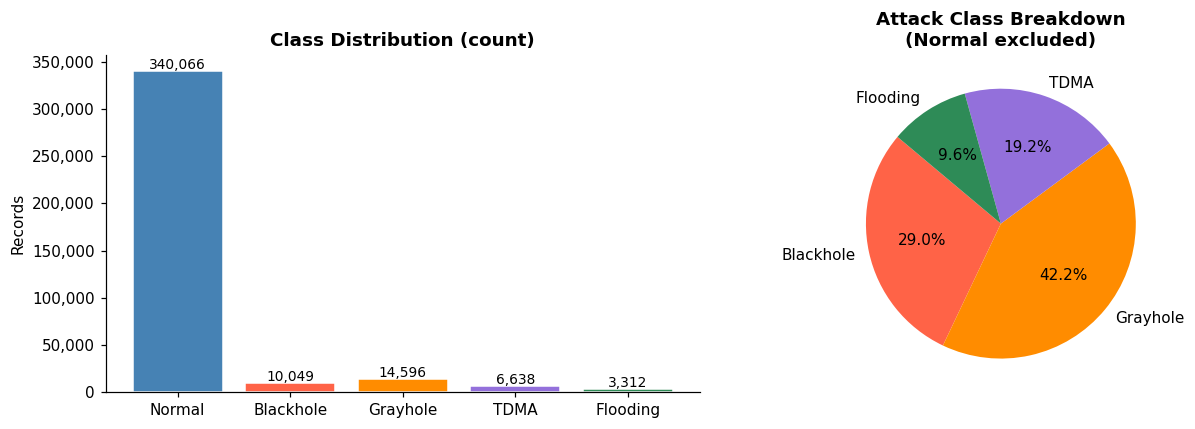

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — raw counts
axes[0].bar(CLASS_ORDER, vc.values, color=CLASS_COLORS, edgecolor='white')
axes[0].set_title('Class Distribution (count)', fontweight='bold')
axes[0].set_ylabel('Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

# Pie — percentage, excluding Normal to see attack split
attack_vc = vc.drop('Normal')
axes[1].pie(attack_vc.values, labels=attack_vc.index,
            colors=CLASS_COLORS[1:], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Attack Class Breakdown\n(Normal excluded)', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/eda_class_distribution.png', bbox_inches='tight')
plt.show()

In [8]:
df['label_binary'] = (df['Attack type'] != 'Normal').astype(int)
bin_vc = df['label_binary'].value_counts().rename({0: 'Normal', 1: 'Attack'})
print('Binary split:')
print(bin_vc)
print(f'\nImbalance ratio (Normal:Attack) = {bin_vc["Normal"]/bin_vc["Attack"]:.1f}:1')

Binary split:
label_binary
Normal    340066
Attack     34595
Name: count, dtype: int64

Imbalance ratio (Normal:Attack) = 9.8:1


## 3. Feature Analysis

In [9]:
df[FEATURE_COLS].describe().round(3)

,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy
count,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000,374661.000
mean,1064.749,0.116,274980.411,22.599,0.268,6.941,0.780,0.737,0.289,0.747,9.687,44.858,73.890,4.569,22.563,2.498,0.306
std,899.646,0.320,389911.222,21.956,2.061,7.044,0.414,4.691,2.755,0.434,14.682,42.574,230.246,19.679,50.262,2.407,0.669
min,50.000,0.000,101000.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,353.000,0.000,107096.000,4.735,0.000,3.000,1.000,0.000,0.000,0.000,1.000,13.000,0.000,0.000,0.000,1.000,0.056
50%,803.000,0.000,116072.000,18.373,0.000,5.000,1.000,0.000,0.000,1.000,3.000,35.000,0.000,0.000,0.000,2.000,0.098
75%,1503.000,0.000,215073.000,33.776,0.000,7.000,1.000,0.000,0.000,1.000,13.000,62.000,0.000,0.000,0.000,4.000,0.218
max,3600.000,1.000,3402100.000,214.275,97.000,117.000,1.000,124.000,99.000,1.000,99.000,241.000,1496.000,241.000,201.935,15.000,45.094


In [10]:
zero_pct = (df[FEATURE_COLS] == 0).mean() * 100
zero_pct = zero_pct.sort_values(ascending=False)
print('Zero-value rate per feature:')
for feat, pct in zero_pct.items():
    bar = '#' * int(pct / 2)
    print(f'  {feat:<22} {pct:5.1f}%  {bar}')

Zero-value rate per feature:
  SCH_S                   95.0%  ###############################################
  JOIN_R                  95.0%  ###############################################
  Is_CH                   88.4%  ############################################
  ADV_S                   88.4%  ############################################
  DATA_R                  85.2%  ##########################################
  dist_CH_To_BS           82.2%  #########################################
  Data_Sent_To_BS         82.2%  #########################################
  SCH_R                   25.3%  ############
  Dist_To_CH              22.0%  ###########
  JOIN_S                  22.0%  ###########
  send_code               22.0%  ###########
  Rank                    20.0%  #########
  DATA_S                  16.1%  ########
  ADV_R                    8.9%  ####
  Expaned Energy           0.0%  
  Time                     0.0%  
  who CH                   0.0%  


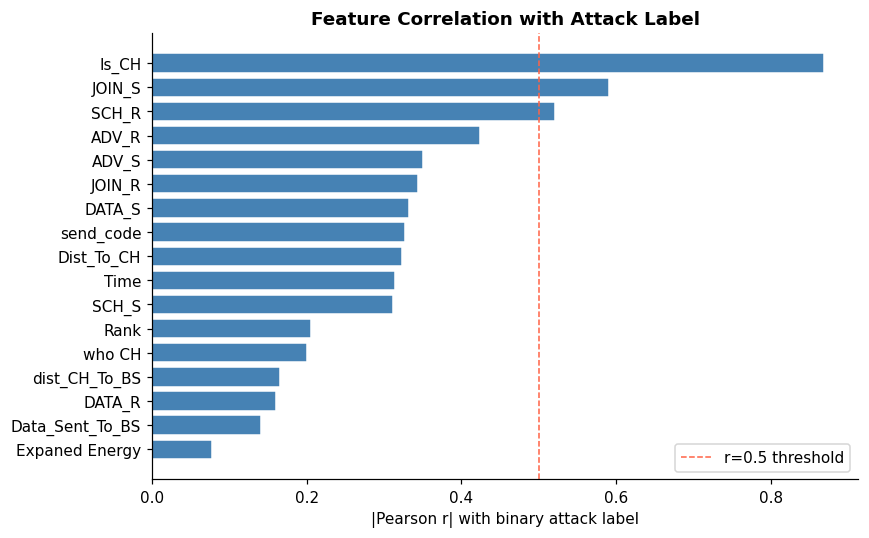

Is_CH              0.8693
JOIN_S             0.5914
SCH_R              0.5211
ADV_R              0.4237
ADV_S              0.3503
JOIN_R             0.3438
DATA_S             0.3316
send_code          0.3266
Dist_To_CH         0.3233
Time               0.3137
SCH_S              0.3111
Rank               0.2057
who CH             0.2003
dist_CH_To_BS      0.1648
DATA_R             0.1605
Data_Sent_To_BS    0.1410
Expaned Energy     0.0778
Name: label_binary, dtype: float64


In [11]:
corrs = df[FEATURE_COLS + ['label_binary']].corr()['label_binary'].drop('label_binary').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(corrs.index[::-1], corrs.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('|Pearson r| with binary attack label')
ax.set_title('Feature Correlation with Attack Label', fontweight='bold')
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='r=0.5 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/eda_feature_correlation.png', bbox_inches='tight')
plt.show()
print(corrs.round(4))

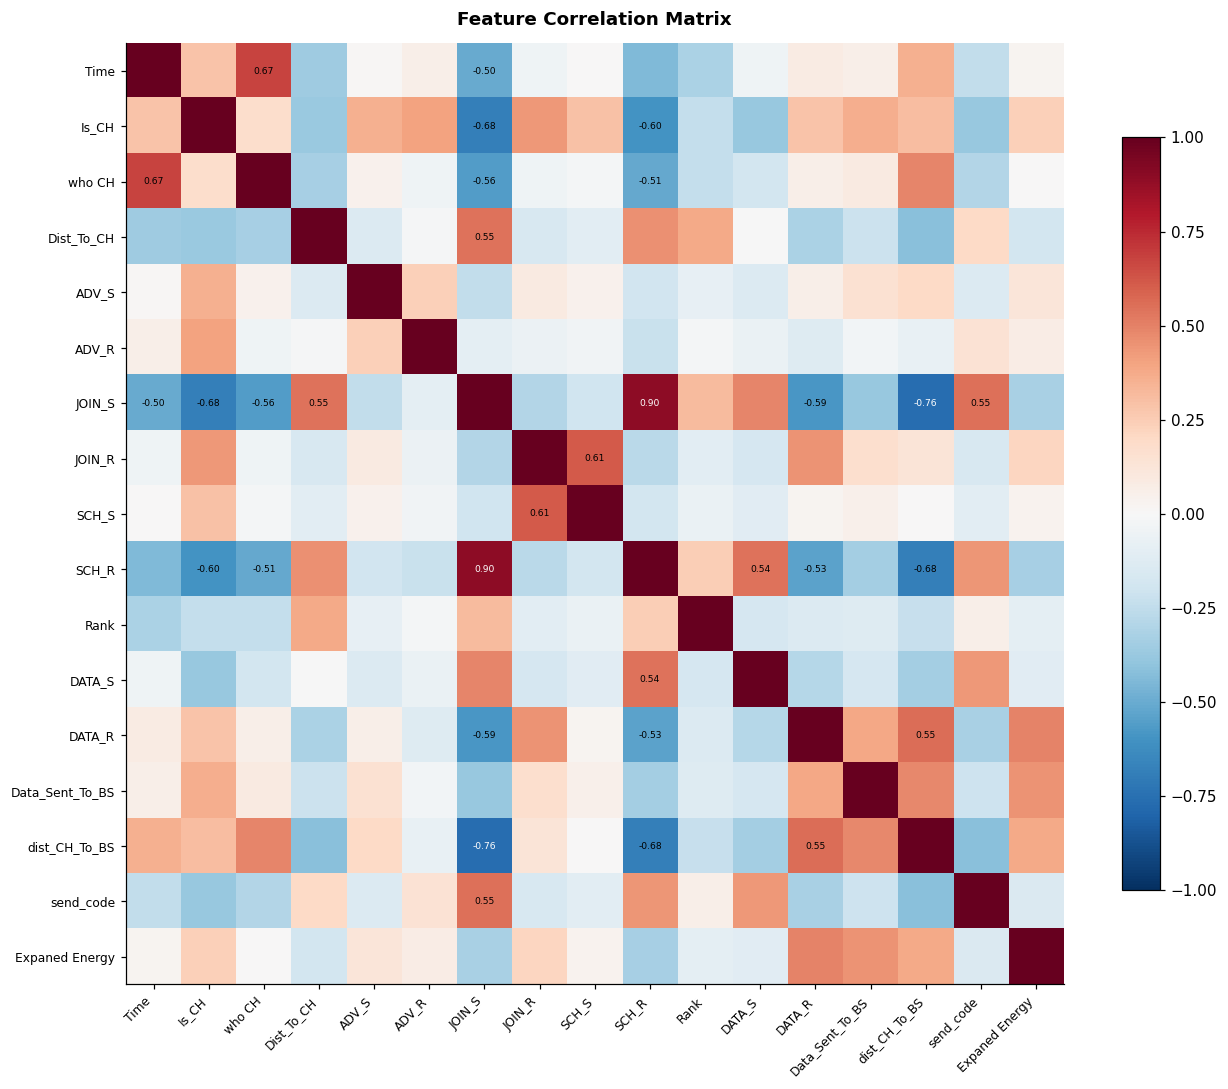

In [12]:
corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ticks = range(len(FEATURE_COLS))
ax.set_xticks(ticks); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(ticks); ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)

# Annotate cells
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5 and i != j:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(val) > 0.75 else 'black')

plt.tight_layout()
plt.savefig('../results/eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [13]:
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, idx, corr_matrix.loc[idx, col])
             for col in upper.columns for idx in upper.index
             if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > 0.7]
print('Highly correlated pairs (|r| > 0.7):')
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f'  {a} <-> {b}: {r:.3f}')

Highly correlated pairs (|r| > 0.7):
  SCH_R <-> JOIN_S: 0.898
  dist_CH_To_BS <-> JOIN_S: -0.762


## 4. Per-Class Behavioral Signatures

In [14]:
class_means = df.groupby('Attack type')[FEATURE_COLS].mean().reindex(CLASS_ORDER).round(3)
class_means

,Time,Is_CH,who CH,Dist_To_CH,ADV_S,ADV_R,JOIN_S,JOIN_R,SCH_S,SCH_R,Rank,DATA_S,DATA_R,Data_Sent_To_BS,dist_CH_To_BS,send_code,Expaned Energy
Attack type,,,,,,,,,,,,,,,,,
Normal,974.748,0.027,250066.612,24.864,0.037,5.989,0.858,0.223,0.016,0.820,10.650,49.361,62.102,3.684,19.920,2.749,0.289
Blackhole,2217.978,1.000,561877.106,0.000,1.000,17.080,0.000,5.187,0.369,0.022,0.000,0.000,305.450,0.000,0.000,0.000,0.188
Grayhole,2284.334,1.000,657800.600,0.000,1.000,19.002,0.000,3.041,0.210,0.004,0.000,0.000,179.674,12.275,75.882,0.000,0.483
TDMA,1426.855,0.936,252346.810,1.779,0.936,5.321,0.061,14.405,14.405,0.060,1.134,3.086,60.953,25.750,22.925,0.172,0.486
Flooding,706.246,1.000,320846.851,0.000,17.125,24.000,0.000,2.516,0.170,0.188,0.000,0.000,141.389,32.893,126.624,0.000,1.225


In [15]:
print('Is_CH rate by class (fraction of records where node is cluster head):')
print(pd.crosstab(df['Attack type'], df['Is_CH'], normalize='index').reindex(CLASS_ORDER).round(4))

Is_CH rate by class (fraction of records where node is cluster head):
Is_CH             0       1
Attack type                
Normal       0.9729  0.0271
Blackhole    0.0000  1.0000
Grayhole     0.0000  1.0000
TDMA         0.0637  0.9363
Flooding     0.0000  1.0000


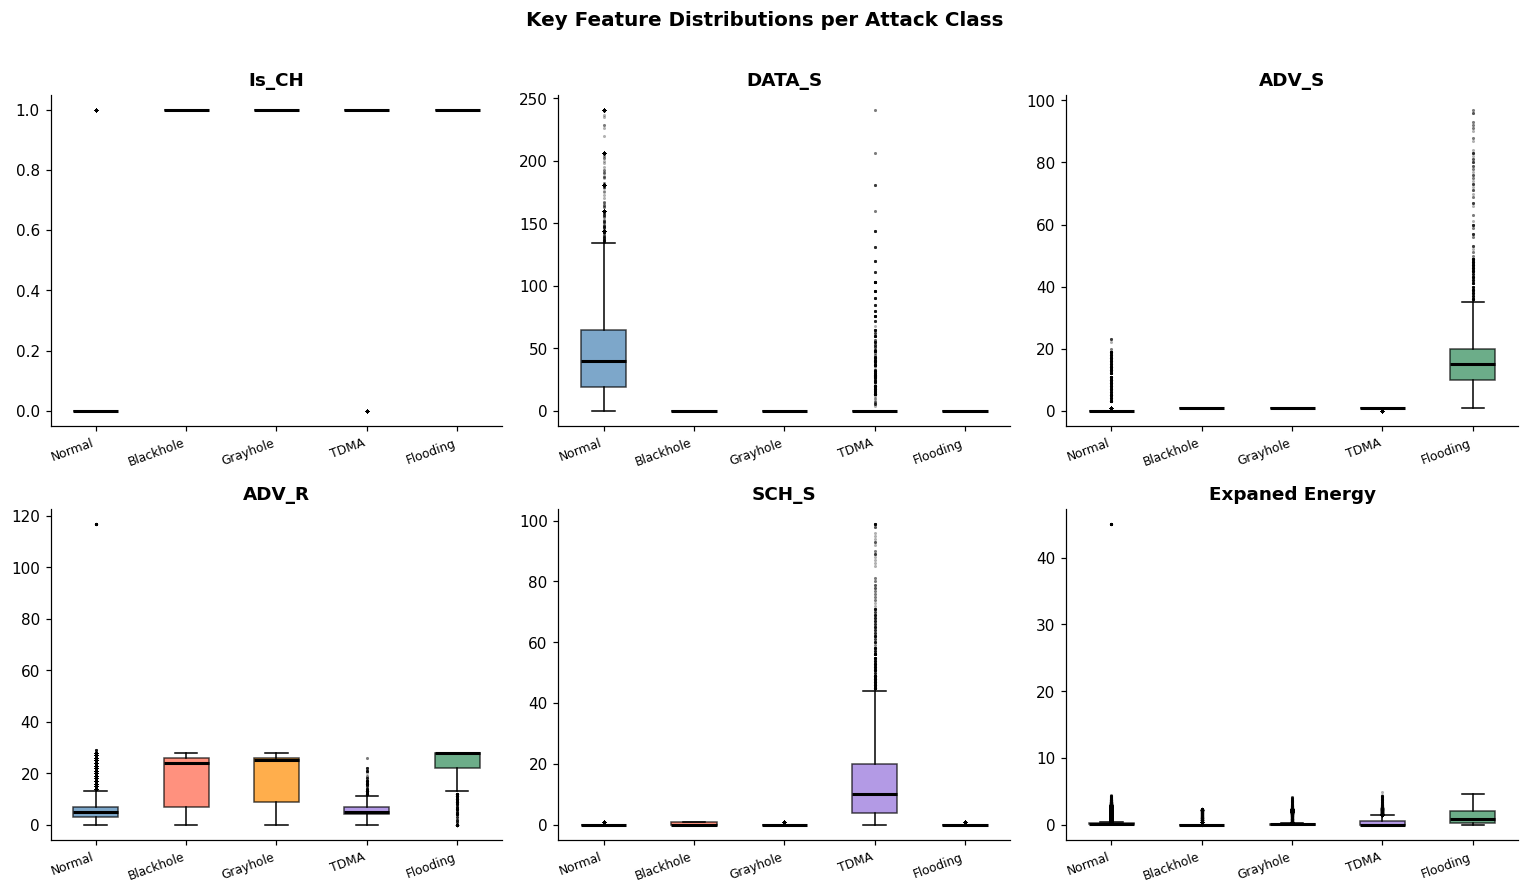

In [16]:
key_features = ['Is_CH', 'DATA_S', 'ADV_S', 'ADV_R', 'SCH_S', 'Expaned Energy']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    vals = [df[df['Attack type'] == cls][feat].values for cls in CLASS_ORDER]
    bp = ax.boxplot(vals, patch_artist=True, medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(CLASS_ORDER, rotation=20, ha='right', fontsize=8)
    ax.set_title(feat, fontweight='bold')

fig.suptitle('Key Feature Distributions per Attack Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/eda_per_class_boxplots.png', bbox_inches='tight')
plt.show()

In [17]:
# DATA_S = 0 for all attack classes except (partially) TDMA — the "drop data" fingerprint
print('DATA_S == 0 rate per class (nodes that forward NO data):')
for cls in CLASS_ORDER:
    sub = df[df['Attack type'] == cls]
    rate = (sub['DATA_S'] == 0).mean() * 100
    print(f'  {cls:<12} {rate:.1f}%')

DATA_S == 0 rate per class (nodes that forward NO data):
  Normal       7.7%
  Blackhole    100.0%
  Grayhole     100.0%
  TDMA         93.8%
  Flooding     100.0%


In [18]:
# Blackhole drops everything; Grayhole forwards some — shown by Data_Sent_To_BS
print('Blackhole vs Grayhole — Data_Sent_To_BS (partial forwarding signature):')
for cls in ['Blackhole', 'Grayhole']:
    sub = df[df['Attack type'] == cls]['Data_Sent_To_BS']
    print(f'  {cls}: mean={sub.mean():.3f}, median={sub.median():.3f}, max={sub.max()}')

Blackhole vs Grayhole — Data_Sent_To_BS (partial forwarding signature):
  Blackhole: mean=0.000, median=0.000, max=0
  Grayhole: mean=12.275, median=1.000, max=140


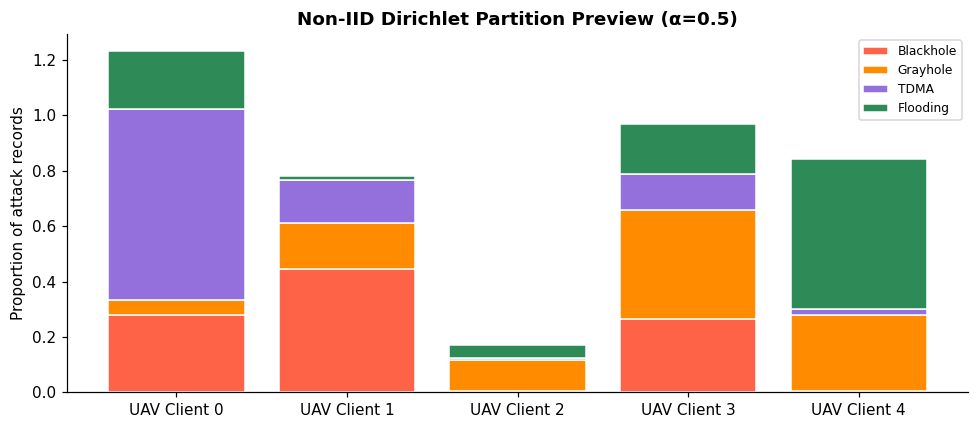

Each UAV client sees a different attack class distribution — motivates FedProx over FedAvg.


In [19]:
# Preview what non-IID UAV partitions look like using Dirichlet sampling
rng = np.random.default_rng(42)
n_clients = 5
alpha = 0.5

attack_classes = [c for c in CLASS_ORDER if c != 'Normal']
attack_df = df[df['Attack type'] != 'Normal'].copy()

proportions = rng.dirichlet([alpha] * n_clients, size=len(attack_classes))

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(n_clients)
for i, cls in enumerate(attack_classes):
    ax.bar(range(n_clients), proportions[i], bottom=bottom,
           label=cls, color=CLASS_COLORS[i+1], edgecolor='white')
    bottom += proportions[i]

ax.set_xticks(range(n_clients))
ax.set_xticklabels([f'UAV Client {i}' for i in range(n_clients)])
ax.set_ylabel('Proportion of attack records')
ax.set_title(f'Non-IID Dirichlet Partition Preview (α={alpha})', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('../results/eda_noniid_partition_preview.png', bbox_inches='tight')
plt.show()
print('Each UAV client sees a different attack class distribution — motivates FedProx over FedAvg.')